In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [33]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [34]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
sc = StandardScaler()

target_column_nugget = "NuggetDiameter (mm)" 
target_column_class = "Category" 


x_train, y_train = get_features_and_target(train_df, target_column_nugget)
x_dev, y_dev = get_features_and_target(dev_df, target_column_nugget)

x_train_scale = sc.fit_transform(X=x_train)
x_dev_scale = sc.transform(x_dev)


# Fit Nugget Estimator


In [35]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train)

# Predict on the test set
predictions_nugget_train = regressor.predict(x_train)
predictions_nugget_dev= regressor.predict(x_dev)


In [36]:
y_train

0      2.63
1      3.34
2      2.76
3      2.57
4      4.72
       ... 
290    3.58
291    3.44
292    4.35
293    3.58
294    3.50
Name: NuggetDiameter (mm), Length: 295, dtype: float64

In [37]:
predictions_nugget_train

array([2.6413379, 3.973597 , 2.683507 , 2.7150526, 4.091856 , 2.6489258,
       3.595269 , 2.682352 , 4.0461564, 2.6793032, 2.7906604, 2.6610904,
       2.6956367, 3.916206 , 3.7111793, 3.7187643, 2.6973155, 4.0762544,
       4.069511 , 4.0735564, 4.0395947, 4.060915 , 4.0760984, 4.0737286,
       4.0789022, 4.0552382, 4.0730796, 4.0646143, 4.0499167, 4.0649114,
       4.0752544, 3.9379754, 3.936605 , 3.7127695, 3.7478573, 3.7524114,
       3.6733074, 3.5081768, 3.4705586, 3.4821124, 3.4818332, 3.4601855,
       3.444871 , 3.449802 , 3.4410396, 3.444778 , 3.4756787, 3.3510962,
       3.3490453, 3.348771 , 3.3370254, 3.3465724, 3.341061 , 3.3421896,
       3.332669 , 3.334197 , 3.3420901, 3.335082 , 3.3264055, 3.3295908,
       3.3300457, 3.3315082, 3.3343792, 3.3365126, 3.3333259, 3.331419 ,
       3.3303308, 3.3314352, 3.332279 , 3.3330493, 3.333987 , 3.3321068,
       3.3405106, 3.3435879, 3.3539567, 3.3526764, 3.342393 , 3.3484516,
       3.3502808, 3.3470917, 3.3453908, 3.3438535, 

In [38]:
mae_nugget_train = mean_absolute_error(y_train, predictions_nugget_train)
rmse_nugget_train = np.sqrt(mean_squared_error(y_train, predictions_nugget_train))
print(f"MAE Nugget Diameter (mm) - Train: {mae_nugget_train}")
print(f"RMSE Nugget Diameter (mm) - Train: {rmse_nugget_train}")    
print(f"percentage error: {mae_nugget_train / np.mean(y_train) * 100:.2f}%")
print(f"percentage error: {rmse_nugget_train / np.mean(y_train) * 100:.2f}%")

MAE Nugget Diameter (mm) - Train: 0.1960806905132229
RMSE Nugget Diameter (mm) - Train: 0.27772811242478324
percentage error: 5.58%
percentage error: 7.90%


# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [39]:
def compute_interfacial_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     f_pull = 1 * (np.pi/4) * (nugget_prediction)**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1).iloc[0]
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((nugget_prediction) + 2*t)*t*365 
     return np.round(f_pull, 1) 

# Fit Model

In [40]:
# Target value

x_train, y_train = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [41]:
def compute_pullforces(x, y, predictions_class, predictions_nugget):
    pullforces = []

    for sample_id, pred, nugget_value in zip(y.index, predictions_class, predictions_nugget):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df, nugget_value)
        else:
            value = compute_pullout_failure(row_x_df, nugget_value)

        pullforces.append(value)

    return np.array(pullforces)


In [42]:
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train, predictions_nugget_train)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev, predictions_nugget_dev)


In [43]:
print(predictions_class_dev)

['Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good']


In [44]:
print(pullforces_dev)

[5725.8        1400.5        5782.4        1402.69995117 6151.4
 1435.59997559 6149.9        1478.09997559 4046.4        3826.5
 3897.         3497.5        3557.9        3492.4        3401.2
 3429.2        3357.2        3404.6        3240.2        3425.6
 3354.5        3377.5        3289.5        3307.5        3330.
 3349.7        3281.5        3316.3        3272.8        3310.1
 3258.3        3274.1        3365.4        3365.2        3262.1
 3392.6        3406.4        3302.3        3333.         3367.4
 3304.5        3400.5        3381.8        3495.         3551.7
 3554.6        3586.6        3588.2        3497.4        3434.8
 3419.4        3403.5        3520.6        3505.4        3526.7
 3515.7        3535.7        3480.5        3513.1        3531.7
 3516.4        3465.2        3486.2        3387.7        3366.1
 3364.5        3330.2        3300.3        3318.9        3364.8
 3336.3        3442.8        3395.6        3397.1        3348.5
 3341.6        3379.         3330.5      

In [45]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_train_delta =  pullforces_train - y_train_Regressor

y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_delta = pullforces_dev - y_dev_Regressor


In [46]:
y_train_Regressor.head(10)

Sample ID
1     2127.7
2     5346.4
4     2350.4
5     2174.8
7     3897.5
9     1932.5
11    3816.0
12    1832.5
15    5634.8
17    2685.9
Name: PullTest (N), dtype: float64

In [47]:
pullforces_train

array([1400.        , 6133.        , 1445.09997559, 1479.19995117,
       6347.1       , 1408.09997559, 5792.4       , 1443.80004883,
       6307.3       , 1440.5       , 1562.80004883, 1421.        ,
       1458.19995117, 6212.4       , 6086.7       , 6112.2       ,
       1460.        , 3847.4       , 3910.7       , 3921.2       ,
       3805.9       , 3950.        , 3885.1       , 3807.9       ,
       3781.4       , 3839.8       , 3830.        , 3839.        ,
       3911.5       , 3869.4       , 3914.9       , 3792.1       ,
       3761.5       , 3599.5       , 3624.9       , 3628.2       ,
       3493.1       , 3507.        , 3328.5       , 3370.8       ,
       3329.6       , 3368.8       , 3412.5       , 3471.1       ,
       3375.6       , 3398.8       , 3469.3       , 3297.5       ,
       3316.2       , 3282.4       , 3334.4       , 3280.9       ,
       3350.8       , 3291.1       , 3331.2       , 3352.5       ,
       3297.7       , 3319.5       , 3360.3       , 3369.4    

In [48]:
y_train_delta.head(10)

Sample ID
1     -727.700000
2      786.600000
4     -905.300024
5     -695.600049
7     2449.600000
9     -524.400024
11    1976.400000
12    -388.699951
15     672.500000
17   -1245.400000
Name: PullTest (N), dtype: float64

In [49]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622
291,60,1200,0,97.32,2636.69,0.622,0.632
292,60,1200,0,98.07,3601.67,0.666,0.633
293,60,1200,0,97.09,4161.74,0.615,0.619


# Fit 2nd Model

In [50]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_delta)

# Predict on the test set
predictions_class_dev = regressor.predict(x_dev)
    

final_pred = pullforces_dev + predictions_class_dev

pred_series = pd.Series(predictions_class_dev, index=x_dev.index)
pull_series = pd.Series(pullforces_dev, index=y_dev.index)

final_pred = pull_series.loc[pred_series.index] - pred_series


In [51]:
pred_series

0     1615.974487
1     -714.230713
2     1605.493530
3     -715.536316
4      944.149902
         ...     
94     610.167603
95     610.172058
96     609.044312
97     606.990967
98     630.791260
Length: 99, dtype: float32

In [52]:
pull_series

0     5725.800000
1     1400.500000
2     5782.400000
3     1402.699951
4     6151.400000
         ...     
94    3565.400000
95    3533.900000
96    3597.700000
97    3552.300000
98    3587.300000
Length: 99, dtype: float64

In [53]:
pullforces_dev

array([5725.8       , 1400.5       , 5782.4       , 1402.69995117,
       6151.4       , 1435.59997559, 6149.9       , 1478.09997559,
       4046.4       , 3826.5       , 3897.        , 3497.5       ,
       3557.9       , 3492.4       , 3401.2       , 3429.2       ,
       3357.2       , 3404.6       , 3240.2       , 3425.6       ,
       3354.5       , 3377.5       , 3289.5       , 3307.5       ,
       3330.        , 3349.7       , 3281.5       , 3316.3       ,
       3272.8       , 3310.1       , 3258.3       , 3274.1       ,
       3365.4       , 3365.2       , 3262.1       , 3392.6       ,
       3406.4       , 3302.3       , 3333.        , 3367.4       ,
       3304.5       , 3400.5       , 3381.8       , 3495.        ,
       3551.7       , 3554.6       , 3586.6       , 3588.2       ,
       3497.4       , 3434.8       , 3419.4       , 3403.5       ,
       3520.6       , 3505.4       , 3526.7       , 3515.7       ,
       3535.7       , 3480.5       , 3513.1       , 3531.7    

In [54]:
final_pred

0     4109.825513
1     2114.730713
2     4176.906470
3     2118.236267
4     5207.250098
         ...     
94    2955.232397
95    2923.727942
96    2988.655688
97    2945.309033
98    2956.508740
Length: 99, dtype: float64

In [55]:
y_dev

0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

# Check Validation Data

In [56]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [57]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")


MAE:  133.24
RMSE: 229.37
R2: 0.59


# Define Model

In [58]:
model_name_nugget = 'TabPFNNugget'
#model_name_nugget = 'RandomForestNugget'

model_name_class = 'TabPFNClassifier'
#model_name_class = 'RandomForestClassifier'

model_name_reg = 'TabPFN'
#model_name_reg = 'RandomForest'

# Cross Validation


Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
192        235              60                400            0      92.76   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
192       3707.1             0.628             0.634  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
192        2616.7                 3.07      Bad      NaN  


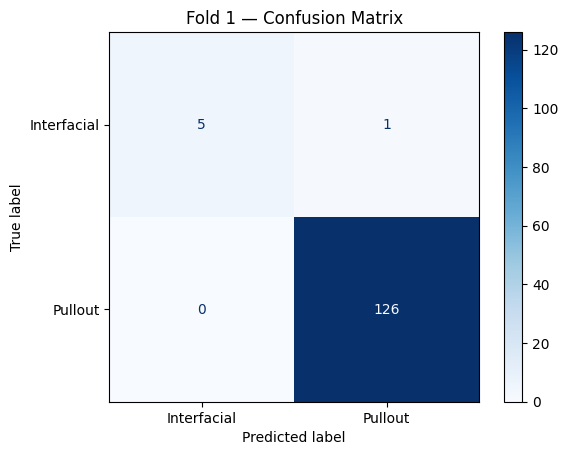

F1 Score: 0.9525691699604744



=== Fold 1 ===
Direct:
 MAE=136.76,
 RMSE=233.29,
 R²=0.62

Pearson correlation (Physics vs True PullForce): 0.5732

Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
384        480              60               1200            0      98.49   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
384      2308.35             0.624             0.626  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
384        1410.3                  1.9      Bad      NaN  


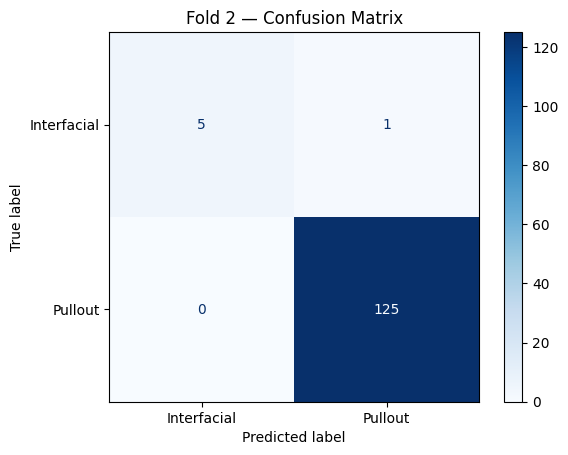

F1 Score: 0.9525534226729446



=== Fold 2 ===
Direct:
 MAE=138.56,
 RMSE=281.78,
 R²=0.64

Pearson correlation (Physics vs True PullForce): 0.4989

Misclassified rows:
     Sample ID  Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  \
154        189              60                400            0      91.17   

     Current (A)  Thickness A (mm)  Thickness B (mm)                Material  \
154       3119.0              0.64             0.633  AISI 1010 carbon steel   

     PullTest (N)  NuggetDiameter (mm) Category Comments  
154        2634.6                  2.7      Bad      NaN  


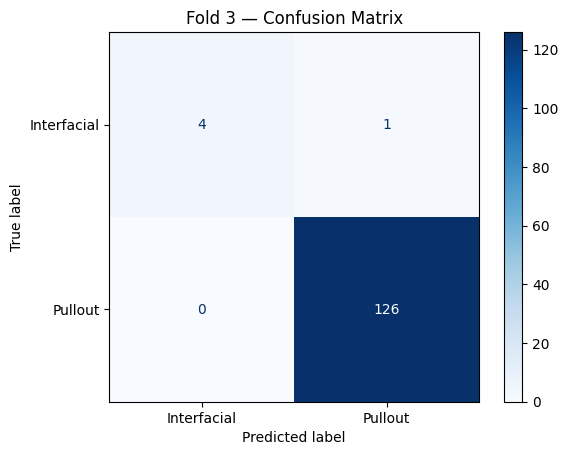

F1 Score: 0.9424681598594642



=== Fold 3 ===
Direct:
 MAE=132.62,
 RMSE=208.79,
 R²=0.70

Pearson correlation (Physics vs True PullForce): 0.5579

=== FINAL CROSS‑VALIDATION RESULTS ===

--- Direct Model ---
MAE mean: 135.98
RMSE mean: 241.29
R² mean: 0.65


In [63]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mapping = {
    "Explode": "Pullout",
    "Good": "Pullout",
    "Bad": "Interfacial"
}

def apply_mapping(arr):
    return np.array([mapping[x] for x in arr])

#Metrics with and without physical inference
direct_mae, direct_rmse, direct_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 
nugget_mae, nugget_rmse = [], []

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):

    # Build fold-specific data
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    train_df["Category"] = apply_mapping(train_df["Category"])
    val_df["Category"] = apply_mapping(val_df["Category"])

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    # Extract features for nugget, class, regression
    x_tr_nug, y_tr_nug = get_features_and_target(x_train, target_column_nugget)
    x_val_nug, y_val_nug = get_features_and_target(x_val, target_column_nugget)

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    # Nugget estimation
    if model_name_nugget == 'TabPFNNugget':
        regressor_nug = TabPFNRegressor()
        regressor_nug.fit(x_tr_nug, y_tr_nug)

        # Predict on sample-level train and val
        predictions_nugget_train = pd.Series(
            regressor_nug.predict(x_tr_nug),
            index=x_tr_nug.index
        )
        predictions_nugget_dev = pd.Series(
            regressor_nug.predict(x_val_nug),
            index=x_val_nug.index
        )

    elif model_name_nugget == 'XGBoostNugget':
        # If you want to use XGBoost, use the sample-level x_tr_nug / x_val_nug
        dtrain = xgb.DMatrix(x_tr_nug, label=y_tr_nug)
        dtest = xgb.DMatrix(x_val_nug, label=y_val_nug)

        params = {
            'objective': 'reg:squarederror',
            'max_depth': 3,
            'eta': 0.2,
            'eval_metric': 'rmse',
        }
        num_boost_round = 10
        bst = xgb.train(params, dtrain, num_boost_round)

        predictions_nugget_train = pd.Series(bst.predict(dtrain), index=x_tr_nug.index)
        predictions_nugget_dev   = pd.Series(bst.predict(dtest),  index=x_val_nug.index)

    elif model_name_nugget == 'RandomForestNugget':
        params = {
            'n_estimators': 98,
            'max_depth': 4,
            'min_samples_split': 3,
            'min_samples_leaf': 4,
            'random_state': 42,
        }
        rf_nug = RandomForestRegressor(**params)
        rf_nug.fit(x_tr_nug, y_tr_nug)

        predictions_nugget_train = pd.Series(rf_nug.predict(x_tr_nug), index=x_tr_nug.index)
        predictions_nugget_dev   = pd.Series(rf_nug.predict(x_val_nug), index=x_val_nug.index)

    nugget_mae.append(mean_absolute_error(y_val_nug, predictions_nugget_dev)) 
    nugget_rmse.append(np.sqrt(mean_squared_error(y_val_nug, predictions_nugget_dev))) 



    # -----------------------------
    # XGBoost CLASSIFIER
    # -----------------------------
    if model_name_class == 'XGBoostClassifier':

        params = {
            "max_depth": 5,
            "learning_rate": 0.3,
            "n_estimators": 177,
            "tree_method": "hist",
            "eval_metric": "mlogloss"
        }

        # Encode labels → integers (required for XGBClassifier)
        le = LabelEncoder()
        y_val_class = le.fit_transform(y_val_class)
        y_tr_class = le.transform(y_tr_class)

        classifier = XGBClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)
        # Reverse LabelEncoder back to original class names
        preds = le.inverse_transform(preds)
        y_val_class = le.inverse_transform(y_val_class)


    # -----------------------------
    # RANDOM FOREST CLASSIFIER
    # -----------------------------
    elif model_name_class == 'RandomForestClassifier':

        
        params = {
            'n_estimators': 27,
            'max_depth': 7,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'max_features': 'log2',
        }

        classifier = RandomForestClassifier(**params)
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

    # -----------------------------
    # TABPFN CLASSIFIER
    # -----------------------------
    elif model_name_class == 'TabPFNClassifier':

        classifier = TabPFNClassifier()
        classifier.fit(x_tr_class, y_tr_class)

        preds = classifier.predict(x_val_class)

    mis_idx = np.where(preds != y_val_class)[0]

    if len(mis_idx) > 0:
        mis_sample_ids = x_val_class.index[mis_idx]   # correct index space
        print("\nMisclassified rows:")
        print(cross_df[cross_df["Sample ID"].isin(mis_sample_ids)])


    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=preds,
        class_labels=["Interfacial", "Pullout"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )

    
    if model_name_reg == 'TabPFN':
        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)

        physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train, predictions_nugget_train) 
        physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev, predictions_nugget_dev)

        y_train_delta = physics_train - y_train_reg 

        # Initialize the regressor
        regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
        # To use TabPFN v2:
        # regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)
        regressor.fit(x_tr_reg, y_train_delta)

        # Predict on the test set
        predictions_regression_dev_without_physics = regressor.predict(x_val_reg)
        final_pred_regression_dev_without_physics  = physics_val - predictions_regression_dev_without_physics




    elif model_name_reg == 'XGBoost':

        # Convert the data into DMatrix format
        dtrain = xgb.DMatrix(x_tr_reg, label=y_train)
        dtest = xgb.DMatrix(x_val_reg, label=y_val_reg)

        # Set the parameters for the XGBoost model
        params = {
            'objective': 'reg:squarederror',
            'max_depth': 1,
            'eta': 0.57,
            'eval_metric': 'rmse',
        }

        # Train the model
        num_boost_round = 13
        bst = xgb.train(params, dtrain, num_boost_round)

        # Make predictions
        predictions_regression_dev_without_physics = bst.predict(dtest)

        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)


    elif model_name_reg == 'RandomForest':
        predictions_class_train = classifier.predict(x_tr_class)
        predictions_class_dev   = classifier.predict(x_val_class)
    
        physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train, predictions_nugget_train) 
        physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev, predictions_nugget_dev)

        y_train_delta = physics_train - y_train_reg 

        # Set the parameters for the Random Forest model
        params = {
                'n_estimators': 19,
                'max_depth': 5,
                'min_samples_split': 6,
                'min_samples_leaf': 3,
                'random_state': 42,
        }
        
        predictions_regression_dev_without_physics = RandomForestRegressor(**params).fit(x_tr_reg, y_train_delta).predict(x_val_reg)
        final_pred_regression_dev_without_physics  = physics_val - predictions_regression_dev_without_physics


    direct_mae.append(mean_absolute_error(y_val_reg, final_pred_regression_dev_without_physics)) 
    direct_rmse.append(np.sqrt(mean_squared_error(y_val_reg, final_pred_regression_dev_without_physics))) 
    direct_r2.append(r2_score(y_val_reg, final_pred_regression_dev_without_physics))

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=final_pred_regression_dev_without_physics,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (/{model_name_reg}) by Category"
    )
   


    print(f"\n=== Fold {fold+1} ===") 
    print(f"Direct:\n MAE={direct_mae[-1]:.2f},\n RMSE={direct_rmse[-1]:.2f},\n R²={direct_r2[-1]:.2f}\n")

    corr = np.corrcoef(physics_train, y_train_reg)[0,1] 
    print(f"Pearson correlation (Physics vs True PullForce): {corr:.4f}")

print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Direct Model ---") 
print(f"MAE mean: {np.mean(direct_mae):.2f}") 
print(f"RMSE mean: {np.mean(direct_rmse):.2f}") 
print(f"R² mean: {np.mean(direct_r2):.2f}")
